In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
test_reuslts_naive = pd.read_csv("test_results/test_results_naive.csv")
test_reuslts_naive_counts = pd.read_csv("test_results/test_results_naive_count.csv")
test_reuslts_smart = pd.read_csv("test_results/test_results_smart.csv")
test_reuslts_smart_counts = pd.read_csv("test_results/test_results_smart_count.csv")

In [31]:
name_translation = {
    'name_match': 'Poklapanje naziva',
    'year_match': 'Poklapanje godine',
    'selling_price_match': 'Poklapanje prodajne cijene',
    'km_driven_match': 'Poklapanje prijeđenih km',
    'fuel_match': 'Poklapanje goriva',
    'seller_type_match': 'Poklapanje tipa prodavača',
    'transmission_match': 'Poklapanje mjenjača',
    'owner_match': 'Poklapanje vlasnika'
}

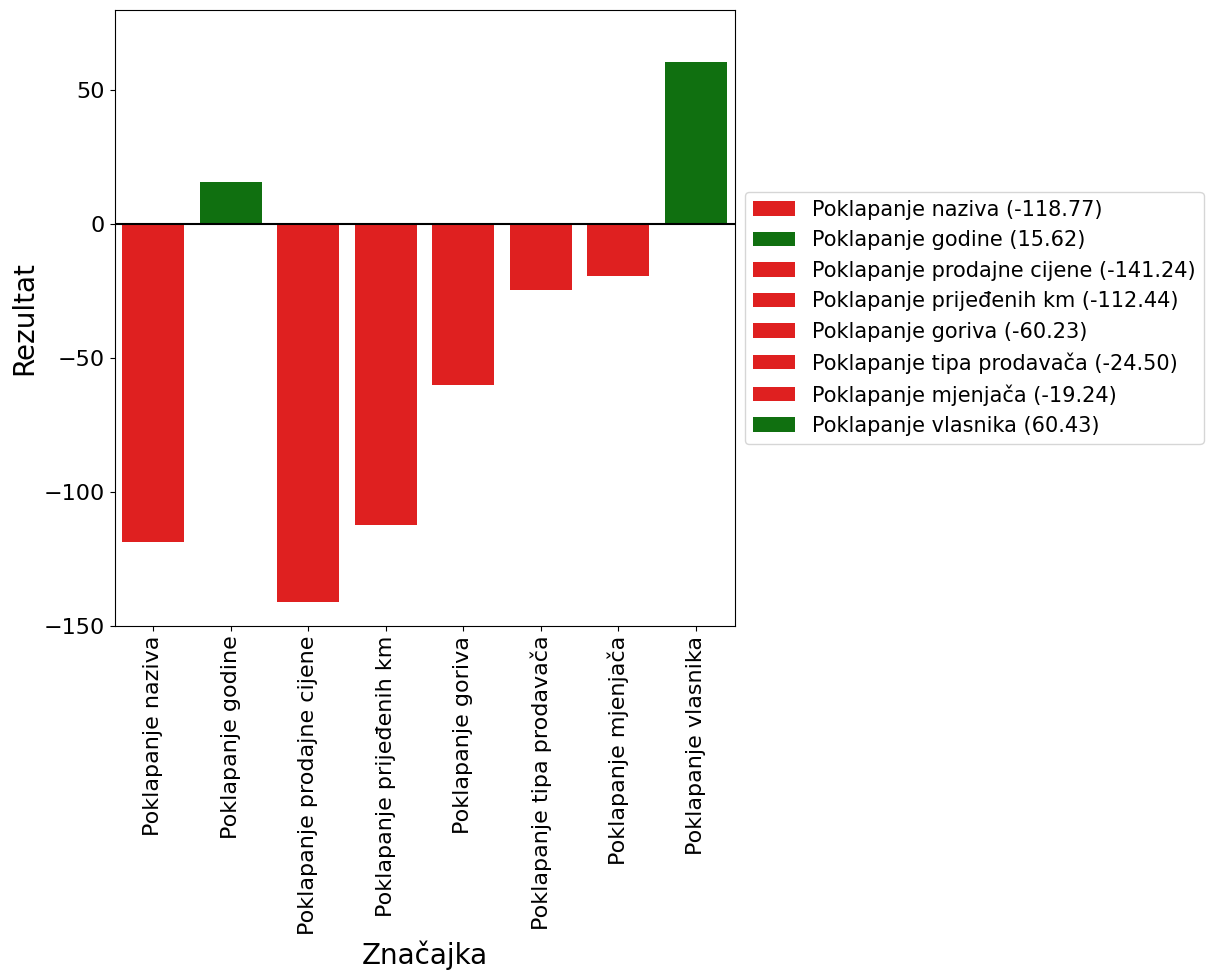

In [32]:
# Prvi graf - Naive model
df = test_reuslts_naive.copy()

# Dodaj hrvatski naziv
df['Name_Croatian'] = df['Name'].map(name_translation)
df['Name_Score'] = df.apply(lambda row: f"{row['Name_Croatian']} ({row['Score']:.2f})", axis=1)

plt.figure(figsize=(8, 8))
colors = ['green' if x > 0 else 'red' for x in df['Score']]

# Stvori custom x-tick labele
croatian_labels = [name_translation[name] for name in df['Name']]

sns.barplot(data=df, x="Name", y="Score", palette=colors, hue="Name_Score", legend=True)

# Postavi hrvatske labele i povećaj font
plt.xticks(ticks=range(len(croatian_labels)), labels=croatian_labels, rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Značajka', fontsize=20)
plt.ylabel('Rezultat', fontsize=20)

# Povećaj font legende
legend = plt.legend(bbox_to_anchor=(1, 0.5), loc='center left', fontsize=15, title_fontsize=15)

plt.ylim(top=80, bottom=-150)
plt.axhline(c='k')
plt.savefig("../analysis/predictive_analysis/test_plots/output1.png")
plt.show()

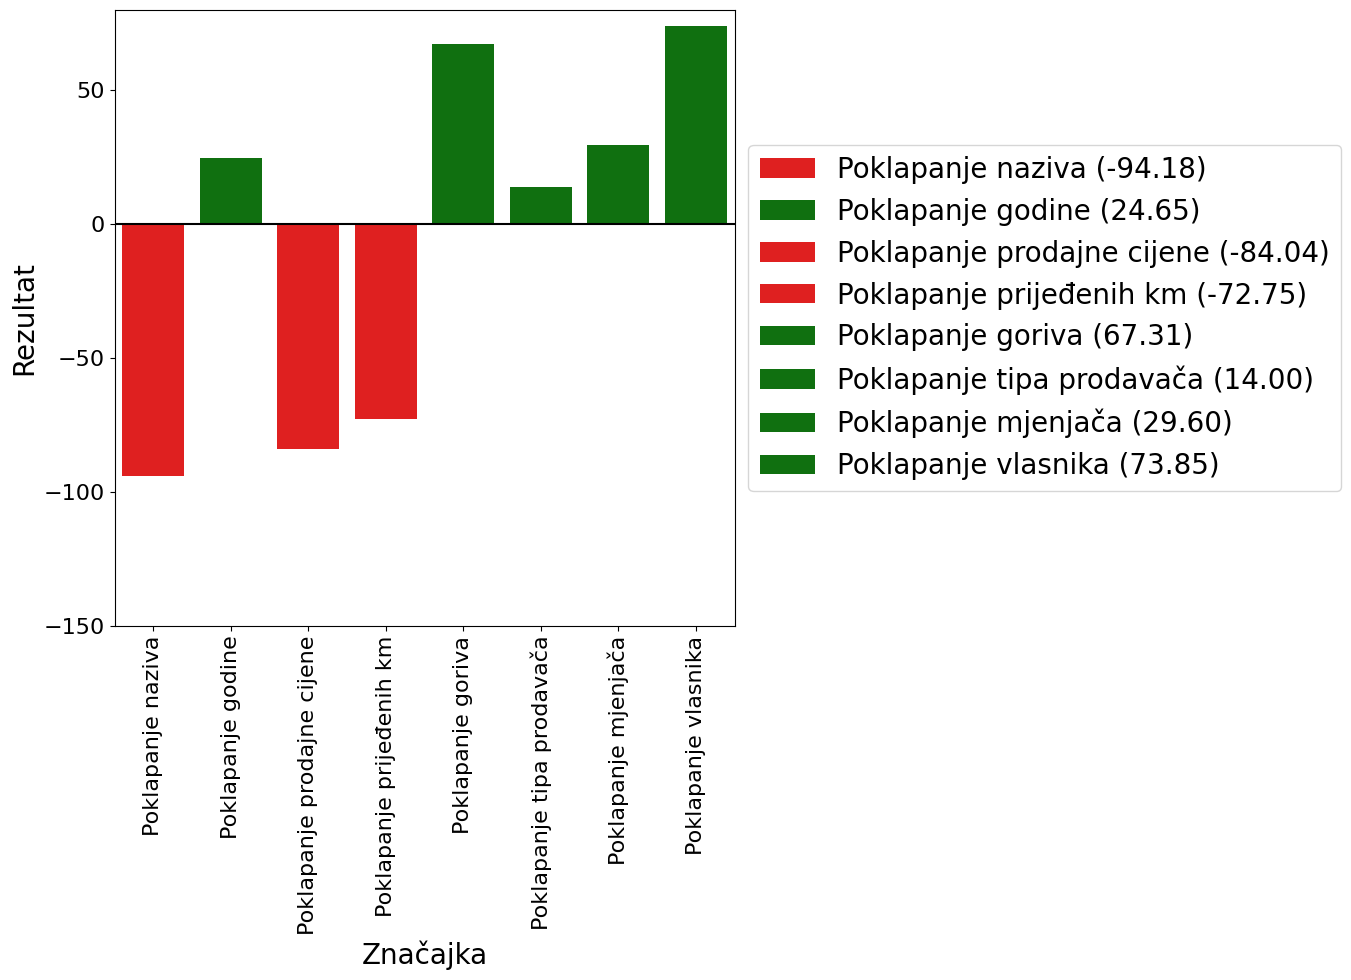

In [33]:

# Drugi graf - Smart model
df = test_reuslts_smart.copy()

# Dodaj hrvatski naziv
df['Name_Croatian'] = df['Name'].map(name_translation)
df['Name_Score'] = df.apply(lambda row: f"{row['Name_Croatian']} ({row['Score']:.2f})", axis=1)

plt.figure(figsize=(8, 8))
colors = ['green' if x > 0 else 'red' for x in df['Score']]

# Stvori custom x-tick labele
croatian_labels = [name_translation[name] for name in df['Name']]

sns.barplot(data=df, x="Name", y="Score", palette=colors, hue="Name_Score", legend=True)

# Postavi hrvatske labele i povećaj font
plt.xticks(ticks=range(len(croatian_labels)), labels=croatian_labels, rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Značajka', fontsize=20)
plt.ylabel('Rezultat', fontsize=20)

# Povećaj font legende
legend = plt.legend(bbox_to_anchor=(1, 0.5), loc='center left', fontsize=20, title_fontsize=20)

plt.ylim(top=80, bottom=-150)
plt.axhline(c='k')
plt.savefig("../analysis/predictive_analysis/test_plots/output2.png")
plt.show()


In [34]:
result_translation = {
    'match_count': 'Točno poklapanje',
    'similar_count': 'Slično poklapanje',
    'different_count': 'Različito',
    'incorrect_count': 'Netočno'
}

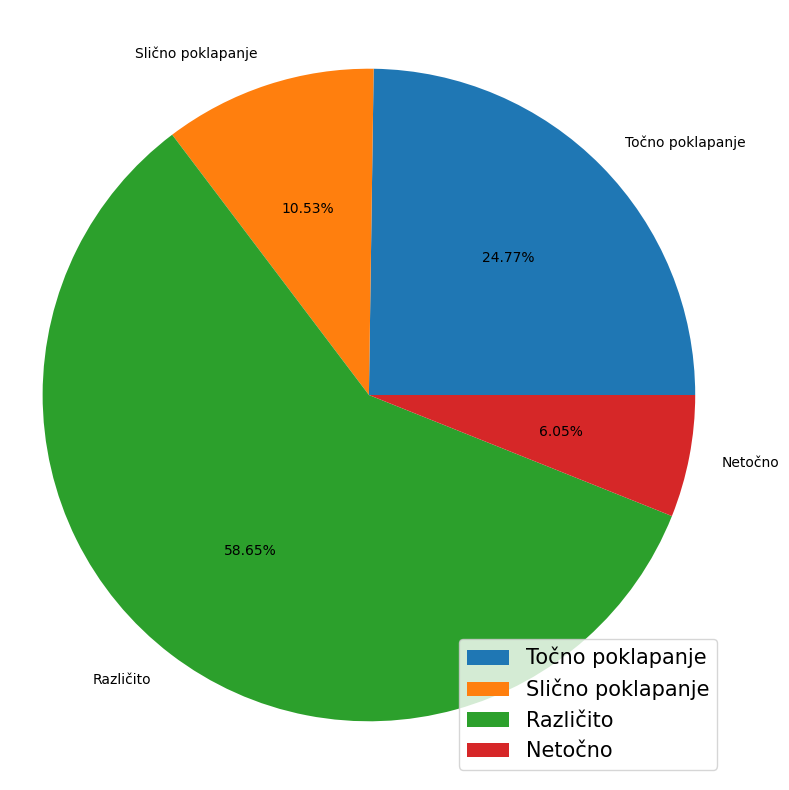

In [35]:
# Prvi graf - Naive model pie chart
df_naive = test_reuslts_naive_counts.copy()
df_naive['Name_Croatian'] = df_naive['Name'].map(result_translation)

plt.figure(figsize=(8,8))
plt.pie(x=df_naive['Count'], labels=df_naive['Name_Croatian'], autopct='%1.2f%%')
plt.axis('equal')

# Povećaj font legende
legend = plt.legend(loc='lower right', fontsize=15)

plt.tight_layout()
plt.savefig("../analysis/predictive_analysis/test_plots/output3.png")
plt.show()


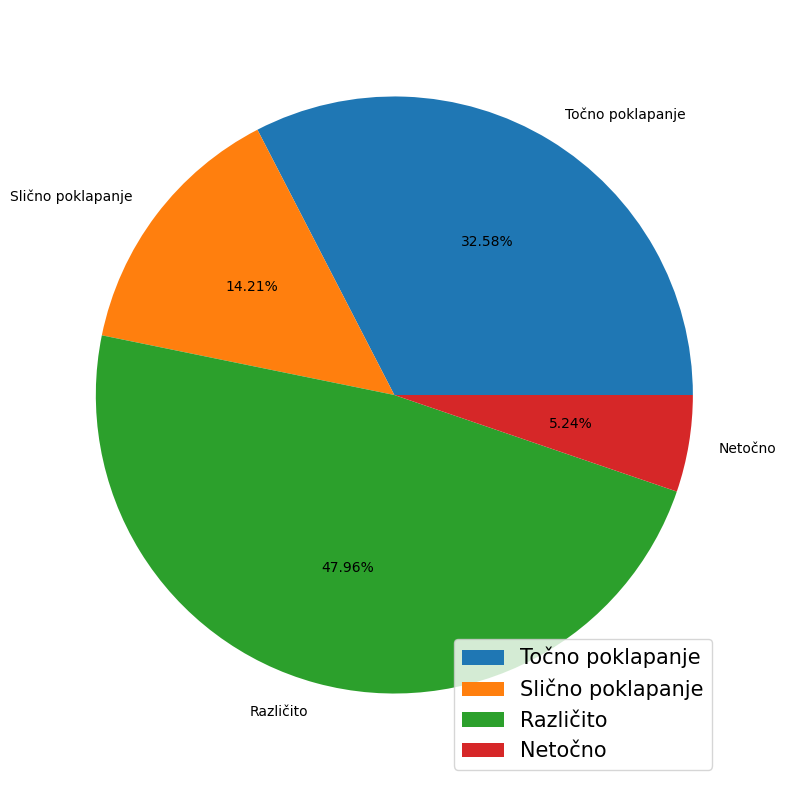

In [36]:
# Drugi graf - Smart model pie chart
df_smart = test_reuslts_smart_counts.copy()
df_smart['Name_Croatian'] = df_smart['Name'].map(result_translation)

plt.figure(figsize=(8,8))
plt.pie(x=df_smart['Count'], labels=df_smart['Name_Croatian'], autopct='%1.2f%%')
plt.axis('equal')

# Povećaj font legende
legend = plt.legend(loc='lower right', fontsize=15)

plt.tight_layout()
plt.savefig("../analysis/predictive_analysis/test_plots/output4.png")
plt.show()
